In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

375


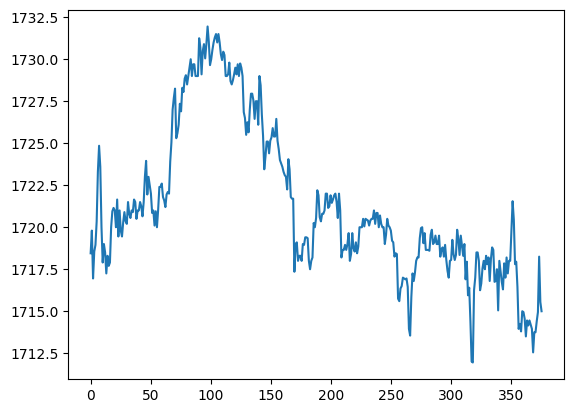

In [ ]:
Adani=pd.read_csv("data/ADANIENT_minute.csv")
Adani.columns=Adani.columns.str.strip()
Day=Adani.loc[(Adani['date'].str[0:10]=="2022-01-03")]
print(len(Day))
plt.plot(np.linspace(0,len(Day),len(Day)),Day['close'])
plt.show()


In [3]:
Adani['dif']=Adani['close']-Adani['close'].shift(1)
Adani['dir']=np.where(Adani['dif']>0,1,0)
Adani.dropna(inplace=True)
print((Adani['dif']))
print(Adani['dir']*Adani['dif'])

1        1.35
2       -2.85
3        1.60
4        0.40
5        1.40
         ... 
92669   -1.90
92670    0.15
92671   -0.60
92672   -2.70
92673   -2.30
Name: dif, Length: 92673, dtype: float64
1        1.35
2       -0.00
3        1.60
4        0.40
5        1.40
         ... 
92669   -0.00
92670    0.15
92671   -0.00
92672   -0.00
92673   -0.00
Length: 92673, dtype: float64


In [4]:
dt=129
Mu2=abs(Adani['dif']).rolling(window=dt-1).mean().shift(1)
Mu2.dropna(inplace=True)
totdif=(Adani['dif'].rolling(window=dt-1).mean()).shift(1)*(dt-1)
totdif.dropna(inplace=True)
Mu1=Adani['dir'].rolling(window=dt-1).mean().shift(1)
Mu1.dropna(inplace=True)
Sigma1=Adani['dir'].rolling(window=dt-1).std().shift(1)
Sigma1.dropna(inplace=True)
moves=[]
for x in range(0,dt+2):
    moves.append(0)
moves.append(0)
for x in range(dt+1,92671):
    mu1=Mu1.loc[x]
    mu2=Mu2.loc[x]
    sigma1=Sigma1.loc[x]
    w=totdif[x]
    p=(2*dt*dt+(2*w*dt)/mu2+mu1/(sigma1*sigma1))/(4*dt*dt+1/(sigma1*sigma1))
    if(p>0.5):
        moves.append(1)
    else:
        moves.append(0)
loggain=[]
for x in range(dt+2,92672):
    loggain.append(moves[x-1]*np.log(Adani['close'].iloc[x+1]/Adani['close'].iloc[x]))
logreturns=np.log(Adani['close']/Adani['close'].shift(1))
logreturns.dropna(inplace=True)
sharperatio=np.sqrt(94500)*(np.mean(loggain)/np.std(loggain))
print(sharperatio)

4.016972157468692


In [5]:
dt=129
cost_per_side=0.0002
Mu2=abs(Adani['dif']).rolling(window=dt-1).mean().shift(1)
Mu2.dropna(inplace=True)
totdif=(Adani['dif'].rolling(window=dt-1).mean()).shift(1)*(dt-1)
totdif.dropna(inplace=True)
Mu1=Adani['dir'].rolling(window=dt-1).mean().shift(1)
Mu1.dropna(inplace=True)
Sigma1=Adani['dir'].rolling(window=dt-1).std().shift(1)
Sigma1.dropna(inplace=True)
Ups=(((Adani['dir']*Adani['dif']).rolling(window=dt-1).mean())/Mu1).shift(1)
Ups.dropna(inplace=True)
Downs=(abs((((1-Adani['dir'])*Adani['dif']).rolling(window=dt-1).mean())/(1-Mu1))).shift(1)
Downs.dropna(inplace=True)
print(Mu2)

129      0.823047
130      0.820312
131      0.803906
132      0.796094
133      0.803516
           ...   
92669    2.204297
92670    2.212500
92671    2.196875
92672    2.184766
92673    2.194922
Name: dif, Length: 92545, dtype: float64


In [6]:
pred=[]
moves=[]
w1=1
for x in range(0,dt+2):
    pred.append(1720)
    moves.append(0)
pred.append(Adani['close'].loc[dt])
for x in range(dt+1,92671):
    mu1=Mu1.loc[x]
    mu2=Mu2.loc[x]
    sigma1=Sigma1.loc[x]
    w=totdif[x]
    p=(2*dt*dt+(2*w*dt)/mu2+mu1/(sigma1*sigma1))/(4*dt*dt+1/(sigma1*sigma1))
    if(p>0.5):
        pred.append(pred[x]+Ups[x]*(2*p-1))
        moves.append(1)
    else:
        pred.append(pred[x]+Downs[x]*(2*p-1))
        moves.append(0)
    #pred.append(pred[x]+(2*p-1)*mu2)


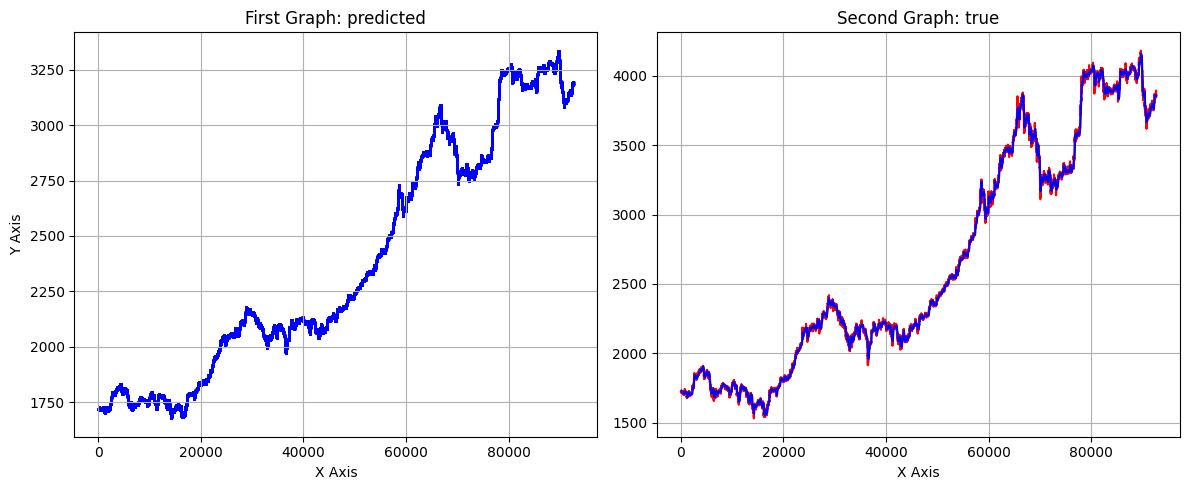

In [7]:
x = np.linspace(0, 92673, 92673)
y1 = pred
y2 = Adani['close']
y3=Day['close'][0:374]
# 2. Create a figure with 1 row and 2 columns
# figsize=(width, height) in inches
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 3. Plot the first graph (Left)
ax1.scatter(x, y1, color='blue', label='pred',s=0.75)
ax1.set_title('First Graph: predicted')
ax1.set_xlabel('X Axis')
ax1.set_ylabel('Y Axis')
ax1.grid(True)
# 4. Plot the second graph (Right)
ax2.plot(x, y2, color='red', label='true')
ax2.set_title('Second Graph: true')
ax2.set_xlabel('X Axis')
ax2.plot(x,Adani['close'].rolling(window=99).mean(),color='blue')
ax2.grid(True)
# ax2.set_ylabel('Y Axis') # Optional if they share the same scale

# 5. Automatically adjust spacing and display
plt.tight_layout()
plt.show()

In [8]:
loggain=[]
trades=0
for x in range(dt+1,92672):
    if(abs(moves[x-1]-moves[x])>0):
        trades+=1
    cost=abs(moves[x-1]-moves[x])*cost_per_side
    loggain.append(moves[x]*np.log(Adani['close'].iloc[x+1]/Adani['close'].iloc[x])-cost)
logreturns=np.log(Adani['close']/Adani['close'].shift(1))
logreturns.dropna(inplace=True)
marketreturn=np.exp(logreturns.sum())-1
stratreturn=np.exp(sum(loggain))-1
sharperatio=np.sqrt(94500)*(np.mean(loggain)/np.std(loggain))
print(trades)

3973


In [9]:
print(marketreturn)
print(stratreturn)
print(sharperatio)
print(moves)

1.2386323991162271
0.3631664900178653
1.2935196829245446
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 